In [23]:
from accelforge import Spec, examples
from pathlib import Path

In [24]:
def get_energy(result):
    """Get total energy in pJ."""
    return float(result.energy())


def get_cycles(result):
    """Get total latency in cycles."""
    return float(result.latency())


def get_component_energy(result, component):
    """Get energy for a specific component."""
    energy = result.energy(per_component=True)
    return float(energy.get(component, 0))

def get_component_cycles(result, component):
    """Get energy for a specific component."""
    latency = result.latency(per_component=True)
    return float(latency.get(component, 0))

# Pure Accelforge Run

In [25]:
# spec = Spec.from_yaml(
#     "../arches/tpu_v4i_with_VPU.yaml",
#     "../workloads/C_4/flash_attention_C_4.yaml"
# )
# results = spec.map_workload_to_arch()

In [26]:
# results

In [27]:
# print("Total Cycles: ", get_cycles(results))
# print("Total Energy: ", get_energy(results))
# print("MainMemory: ", get_component_energy(results, 'MainMemory'))
# print("GlobalBuffer: ", get_component_energy(results, 'GlobalBuffer'))
# print()
# print("ScalarBuffer: ", get_component_energy(results, 'ScalarBuffer'))
# print("ScalarUnit: ", get_component_energy(results, 'ScalarUnit'))
# print()
# print("VpuBuffer: ", get_component_energy(results, 'VpuBuffer'))
# print("VPU: ", get_component_energy(results, 'VPU'))
# print()
# print("MxuBuffer: ", get_component_energy(results, 'MxuBuffer'))
# print("MXU: ", get_component_energy(results, 'MXU'))

# P = 1

In [28]:
# QK
P_1_QK_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_QK.yaml",
    "../workloads/C_1/flash_attention_C_1_QK.yaml"
)
P_1_QK_results = P_1_QK_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components run
Generating jobs:   0%|              | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum QK_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum QK_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 1it [00:00,  6.82it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 2it [00:00,  2.20it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 3it [00:01,  1.66it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 4it [00:01,  2.20it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 6it [00:01,  4.07it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 11it [00:02, 10.11it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 19it [00:02, 21.07it/s]
Generating pmapping templates for compute MXU Einsum QK_1: 32it [00:02, 13.76it/s]
Generating jobs: 100%|██████| 1/1 [00:02<00:00,  2.43s/it]


Einsum QK_1 has 32 pmapping jobs:
	0	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	1	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	2	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] S-reuse_weight2-e  S-reuse_weight1-m_chunk  [K_1 in MxuBuffer] T-m  [QK_1 in MxuBuffer] T-e  MXU computes QK_1
	3	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  [K_1 in GlobalBuffer] T-m  S-reuse_weight2-e  S-reuse_weight1-m_chunk  [QK_1 in MxuBuffer] T-e  [K_1 in MxuBuffer] T-m  MXU computes QK_1
	4	[QK_1 in MainMemory] [Q in MainMemory] [K_1 in MainMemory] T-b  T-e  T-h  T-m  [Q in GlobalBuffer] T-m_chunk  S-reuse_

Generating pmappings: 100%|█| 32/32 [00:10<00:00,  3.06it/
Grouping pmappings for QK_1: 100%|█| 1/1 [00:00<00:00, 24.
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 392.91it/


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 1445.31


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=8.80e-03
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 830.39i


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|██| 1/1 [00:00<00:00, 8490.49it/s]


Dirty joining mapping(s) valid & optimal! Returning...


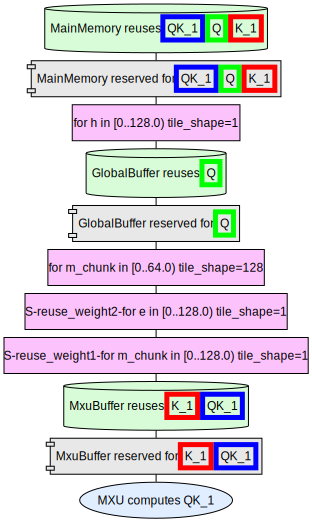

In [29]:
# QK
P_1_QK_results

In [30]:
# QK
print("Total Cycles: ", get_cycles(P_1_QK_results))
print("Total Energy: ", get_energy(P_1_QK_results))
print("MainMemory: ", get_component_energy(P_1_QK_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_QK_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_QK_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_QK_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_QK_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_QK_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_QK_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_QK_results, 'MXU'))

Total Cycles:  0.00022033011191524565
Total Energy:  0.008799588557484826
MainMemory:  0.00760829821228981
GlobalBuffer:  1.6079912959900848e-05

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0011639361487674573
MXU:  1.1274289152e-05


In [31]:
# SM
P_1_SM_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU.yaml",
    "../workloads/C_1/flash_attention_C_1_SM.yaml"
)
P_1_SM_results = P_1_SM_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components run
Generating pmapping templates for compute ScalarUnit Einsum max_1: 10it [00:00, 98.27it/s]
Generating pmapping templates for compute MXU Einsum max_1: 0it [00:00, ?it/s]0:00, 105.79it/s]
Generating pmapping templates for compute ScalarUnit Einsum exp_1: 16it [00:00, 112.57it/s]
Generating pmapping templates for compute VPU Einsum max_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum sum_1: 16it [00:00, 110.93it/s]
Generating pmapping templates for compute ScalarUnit Einsum softmax_1: 16it [00:00, 110.93it/s]
Generating pmapping templates for compute MXU Einsum exp_1: 0it [00:00, ?it/s]t/s]
Generating pmapping templates for compute MXU Einsum sum_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum softmax_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum exp_1: 0it [00:00, ?it/s]t/s]
Generating pmapping templates for compute VPU Einsum sum_1: 0it [00

Einsum max_1 has 10 pmapping jobs:
	0	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	1	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	2	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarBuffer] T-m_chunk  ScalarUnit computes max_1
	3	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  T-m_chunk  [QK_1 in GlobalBuffer] S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [max_1 in ScalarBuffer] T-m_chunk  [QK_1 in ScalarBuffer] ScalarUnit computes max_1
	4	[max_1 in MainMemory] [QK_1 in MainMemory] T-b  T-h  T-m  [max_1 in GlobalBuffer] T-m_chunk  S-Z-m_chunk  S-Z-m  S-Z-h  S-Z-b  [QK_1 in ScalarBuffer] [max_1 in ScalarB

Generating pmappings: 100%|█| 58/58 [00:04<00:00, 11.95it/
Grouping pmappings for max_1: 100%|█| 1/1 [00:00<00:00, 53
Grouping pmappings for exp_1: 100%|█| 5/5 [00:00<00:00, 93
Grouping pmappings for sum_1: 100%|█| 6/6 [00:00<00:00, 97
Grouping pmappings for softmax_1: 100%|█| 5/5 [00:00<00:00
Compressing pmappings: 100%|█| 4/4 [00:00<00:00, 106.91it/


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 17/17 [00:00<00:00, 632.6


...

Dirty pruning pmappings: 100%|█| 17/17 [00:00<00:00, 666.7


Dirty joining uses 100.00% of the pmappings
Filtered 319 -> 319 (100.00% kept) pmappings


Joining pmappings for max_1 <--> exp_1 (2/4): 100%|█| 5/5 
Joining pmappings for exp_1 <--> sum_1 (3/4): 100%|█| 6/6 
Joining pmappings for sum_1 <--> softmax_1 (4/4): 100%|█| 
Final consolidate: 100%|███| 6/6 [00:00<00:00, 435.64it/s]


Dirty joining mapping(s) valid & optimal! Returning...


/Users/mayarebholz/6.5930/accelforge/accelforge/mapper/FFM/_join_pmappings/join_pmappings.py:368: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  joined.data[f"Total<SEP>{MAPPING_COLUMN}"] = [


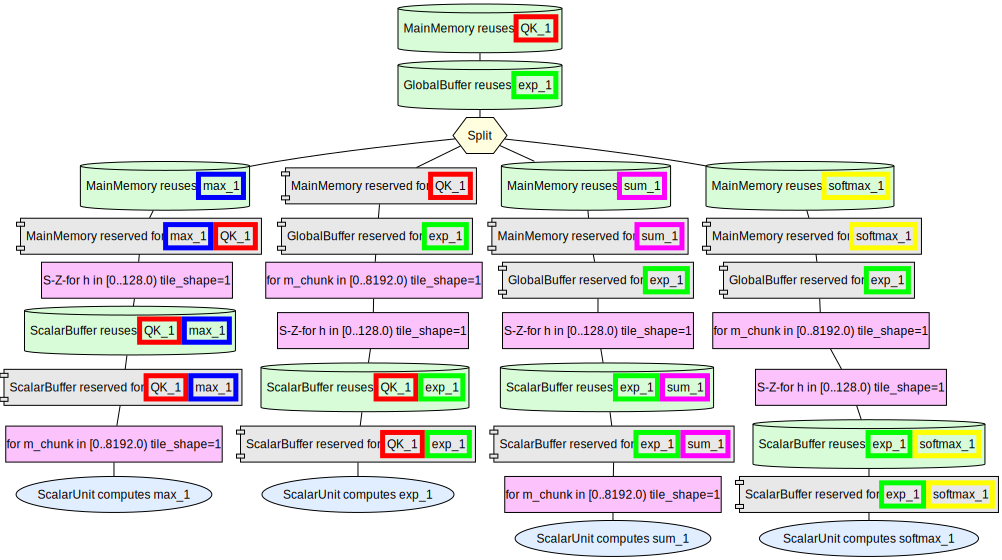

In [32]:
# SM
P_1_SM_results

In [33]:
# SM
print("Total Cycles: ", get_cycles(P_1_SM_results))
print("Total Energy: ", get_energy(P_1_SM_results))
print("MainMemory: ", get_component_energy(P_1_SM_results, 'MainMemory'))
print("GlobalBuffer: ", get_component_energy(P_1_SM_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_SM_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_SM_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_SM_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_SM_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_SM_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_SM_results, 'MXU'))

Total Cycles:  3.1207619031192735e-05
Total Energy:  0.00026967458772848114
MainMemory:  0.0001769301371279397
GlobalBuffer:  5.133828199177515e-05

ScalarBuffer:  3.6373004648983034e-05
ScalarUnit:  5.0331648e-06

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0
MXU:  0.0


In [34]:
# AV
P_1_AV_spec = Spec.from_yaml(
    "../arches/tpu_v4i_with_VPU_AV.yaml",
    "../workloads/C_1/flash_attention_C_1_AV.yaml"
)
P_1_AV_results = P_1_AV_spec.map_workload_to_arch()

Getting energy, latency, and leak power for components run
Generating jobs:   0%|              | 0/1 [00:00<?, ?it/s]
Generating pmapping templates for compute ScalarUnit Einsum AV_1: 0it [00:00, ?it/s]

Generating pmapping templates for compute MXU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 11it [00:00, 101.51it/s]
Generating pmapping templates for compute MXU Einsum AV_1: 32it [00:00, 99.04it/s] 

Generating pmapping templates for compute VPU Einsum AV_1: 0it [00:00, ?it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 12it [00:00, 112.87it/s]
Generating pmapping templates for compute VPU Einsum AV_1: 32it [00:00, 106.50it/s]
Generating jobs: 100%|██████| 1/1 [00:00<00:00,  1.45it/s]


Einsum AV_1 has 64 pmapping jobs:
	0	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	1	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	2	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] S-reuse_weight2-m_chunk  S-reuse_weight1-e  [AV_1 in MxuBuffer] T-m_chunk  [V_1 in MxuBuffer] T-m  MXU computes AV_1
	3	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  T-e  T-h  T-m  [AV_1 in GlobalBuffer] T-m_chunk  S-reuse_weight2-m_chunk  S-reuse_weight1-e  [V_1 in MxuBuffer] T-m  [AV_1 in MxuBuffer] T-m_chunk  MXU computes AV_1
	4	[softmax_1 in MainMemory] [V_1 in MainMemory] [AV_1 in MainMemory] T-b  

Generating pmappings: 100%|█| 64/64 [00:07<00:00,  8.17it/
Grouping pmappings for AV_1: 100%|█| 1/1 [00:00<00:00, 14.
Compressing pmappings: 100%|█| 1/1 [00:00<00:00, 529.12it/


Dirty joining with resource usage <= 1.02× optimal
Dirty joining with objectives <= 2× optimal


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 1615.68


...

Filtering out pmappings worse than the following:
	Total<SEP>energy=8.78e-03
Final clean join.


Dirty pruning pmappings: 100%|█| 1/1 [00:00<00:00, 1766.77


Dirty joining uses 100.00% of the pmappings
Filtered 1 -> 1 (100.00% kept) pmappings


Final consolidate: 100%|█| 1/1 [00:00<00:00, 12671.61it/s]


Dirty joining mapping(s) valid & optimal! Returning...


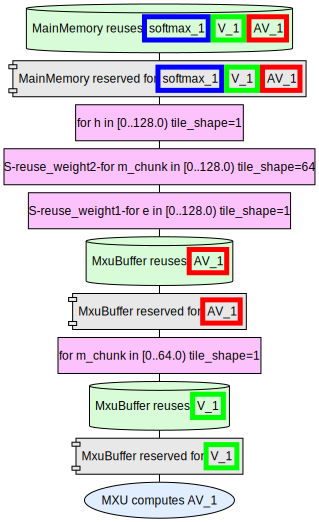

In [35]:
# AV
P_1_AV_results

In [36]:
# AV
print("Total Cycles: ", get_cycles(P_1_AV_results))
print("Total Energy: ", get_energy(P_1_AV_results))
print("MainMemory: ", get_component_energy(P_1_AV_results, 'MainMemory'))
print("MainMemory cycles: ", get_component_cycles(P_1_AV_results, 'MainMemory'))

print("GlobalBuffer: ", get_component_energy(P_1_AV_results, 'GlobalBuffer'))
print()
print("ScalarBuffer: ", get_component_energy(P_1_AV_results, 'ScalarBuffer'))
print("ScalarUnit: ", get_component_energy(P_1_AV_results, 'ScalarUnit'))
print()
print("VpuBuffer: ", get_component_energy(P_1_AV_results, 'VpuBuffer'))
print("VPU: ", get_component_energy(P_1_AV_results, 'VPU'))
print()
print("MxuBuffer: ", get_component_energy(P_1_AV_results, 'MxuBuffer'))
print("MXU: ", get_component_energy(P_1_AV_results, 'MXU'))
print("MXU cycles: ", get_component_cycles(P_1_AV_results, 'MXU'))


Total Cycles:  0.00022033011191524565
Total Energy:  0.008783508666051836
MainMemory:  0.007608298315443871
MainMemory cycles:  0.00022033011191524565
GlobalBuffer:  0.0

ScalarBuffer:  0.0
ScalarUnit:  0.0

VpuBuffer:  0.0
VPU:  0.0

MxuBuffer:  0.0011639361778712878
MXU:  1.1274289152e-05
MXU cycles:  7.801904757798184e-06


In [37]:
# Gathered Results
print("QK Total Cycles: ", get_cycles(P_1_QK_results))
print("QK Total Energy: ", get_energy(P_1_QK_results))
print("SM Total Cycles: ", get_cycles(P_1_SM_results))
print("SM Total Energy: ", get_energy(P_1_SM_results))
print("AV Total Cycles: ", get_cycles(P_1_AV_results))
print("AV Total Energy: ", get_energy(P_1_AV_results))

QK Total Cycles:  0.00022033011191524565
QK Total Energy:  0.008799588557484826
SM Total Cycles:  3.1207619031192735e-05
SM Total Energy:  0.00026967458772848114
AV Total Cycles:  0.00022033011191524565
AV Total Energy:  0.008783508666051836


In [39]:
# Total Pipeline Results
print("Total Pipeline Cycles: ", get_cycles(P_1_QK_results)+get_cycles(P_1_SM_results)+get_cycles(P_1_AV_results))
print("Total Pipeline Energy: ", get_energy(P_1_QK_results)+get_energy(P_1_SM_results)+get_energy(P_1_AV_results))

Total Pipeline Cycles:  0.00047186784286168404
Total Pipeline Energy:  0.017852771811265142
